In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv("happiness.csv", index_col=1)

In [4]:
df

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
Country or region,,,,,,,,
Finland,1,7.632,1.305,1.592,0.874,0.681,0.202,0.393
Norway,2,7.594,1.456,1.582,0.861,0.686,0.286,0.340
Denmark,3,7.555,1.351,1.590,0.868,0.683,0.284,0.408
Iceland,4,7.495,1.343,1.644,0.914,0.677,0.353,0.138
Switzerland,5,7.487,1.420,1.549,0.927,0.660,0.256,0.357
...,...,...,...,...,...,...,...,...
Yemen,152,3.355,0.442,1.073,0.343,0.244,0.083,0.064
Tanzania,153,3.303,0.455,0.991,0.381,0.481,0.270,0.097
South Sudan,154,3.254,0.337,0.608,0.177,0.112,0.224,0.106


In [5]:
df = df.rename(columns={"Overall rank":"rank", "GDP per capita":"GDP", "Social support":"Social", 
                        "Healthy life expectancy": "Health", "Freedom to make life choices": "Freedom", "Perceptions of corruption": "Corruption"})

In [6]:
df = df.drop("rank", axis=1)

In [7]:
df["Corruption"] = df["Corruption"].fillna(df["Corruption"].mean())

# EDA

<Figure size 600x600 with 0 Axes>

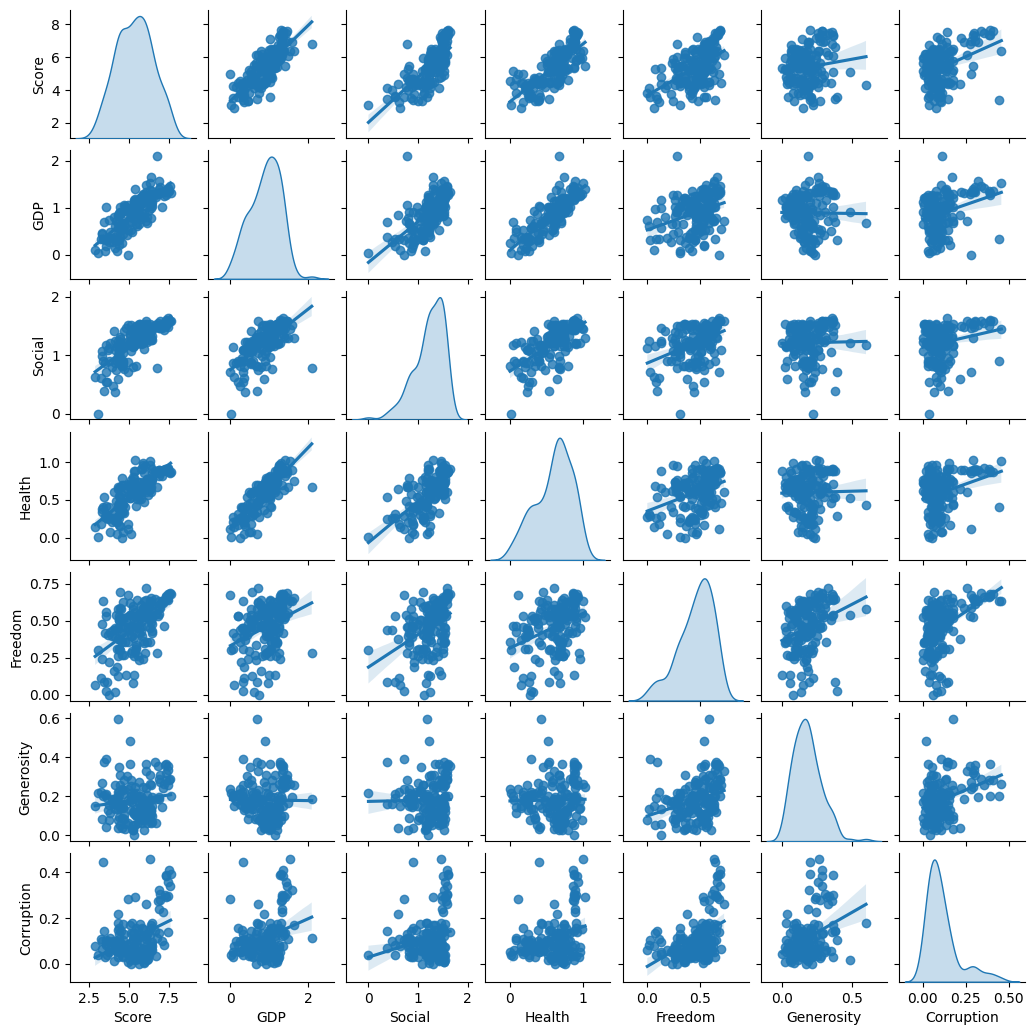

In [8]:
plt.figure(figsize=[6, 6])
sns.pairplot(df, diag_kind="kde", kind="reg", height=1.5)

<Axes: >

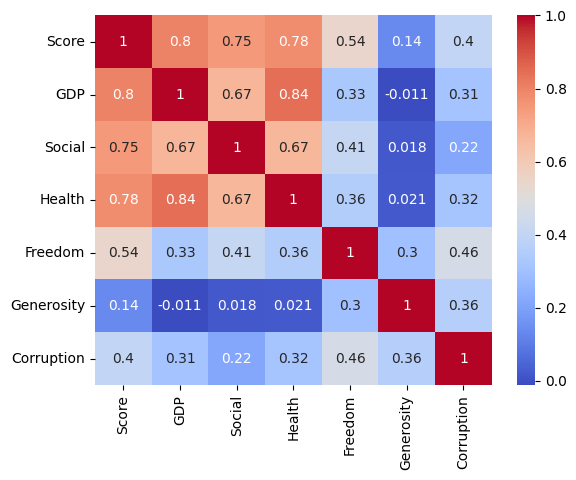

In [9]:
sns.heatmap(df.corr(), cmap="coolwarm", annot=True)

In [10]:
# Calculate VIFs
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calculate_vif(X):
    vif = pd.DataFrame()
    vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif["features"] = X.columns
    return vif
X = df.copy()
X = X.drop("Score", axis=1)
vif = calculate_vif(X)
print(vif)

   VIF Factor    features
0   23.655601         GDP
1   22.734476      Social
2   25.845194      Health
3   12.952704     Freedom
4    4.814285  Generosity
5    3.413514  Corruption


In [11]:
# PCA for correlated features
from sklearn.decomposition import PCA
pca = PCA(n_components=1)
pca.fit(df[["Health", "Social", "GDP"]])
df["PCA"] = pca.transform(df[["Health", "Social", "GDP"]])
df = df.drop(["Health", "Social", "GDP"], axis=1)

In [12]:
df = df.sort_index()

<Axes: >

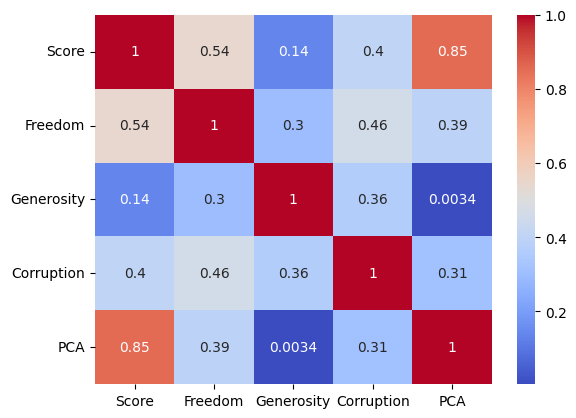

In [13]:
sns.heatmap(df.corr(), cmap="coolwarm", annot=True)

<Axes: >

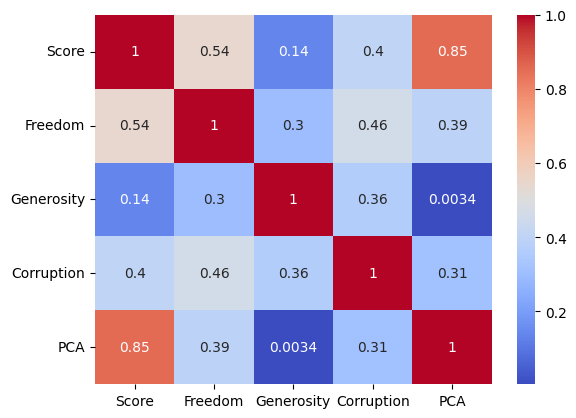

In [14]:
sns.heatmap(df.corr(), cmap="coolwarm", annot=True)

# Assess the linearity of our predictors

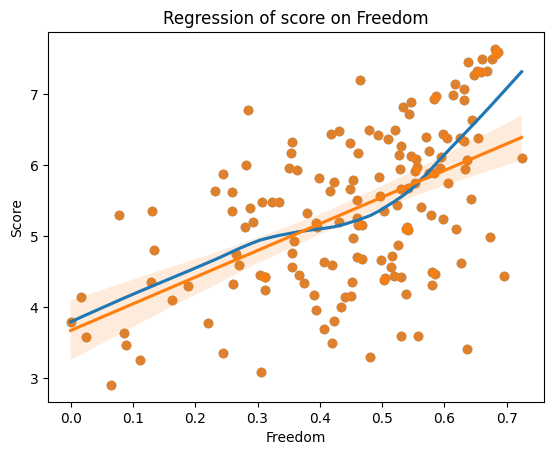

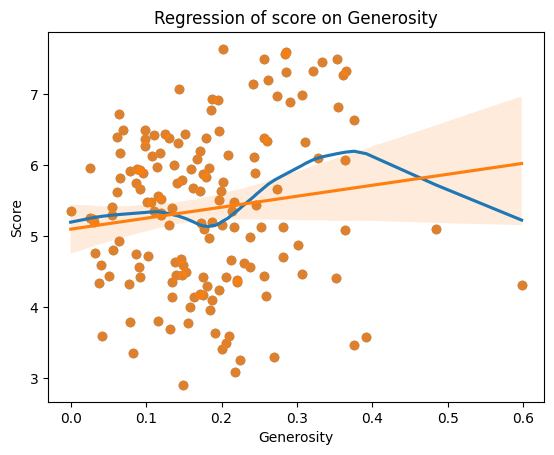

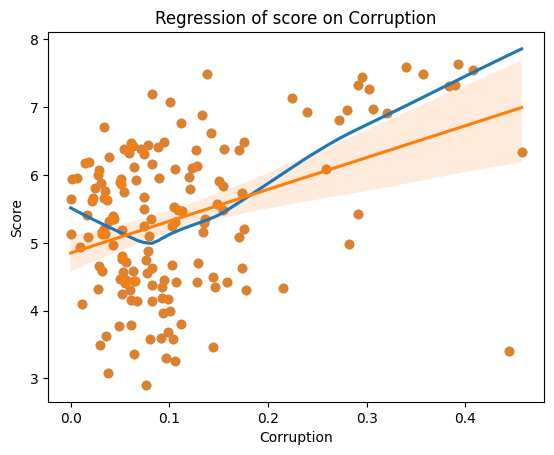

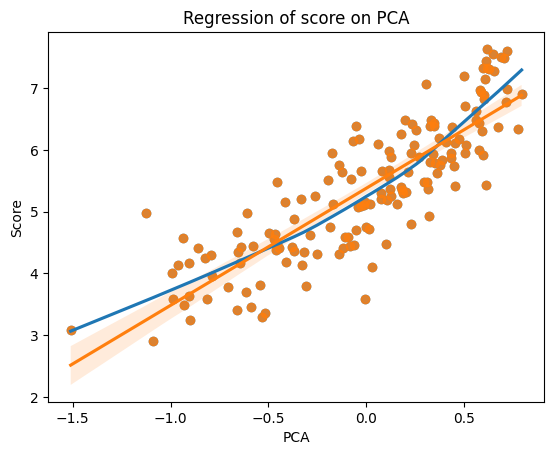

In [15]:
for feature in df.drop("Score", axis=1).columns:
    sns.regplot(df, x=feature, y="Score", lowess=True)
    sns.regplot(df, x=feature, y="Score", lowess=False)
    plt.title(f"Regression of score on {feature}")
    plt.show()

In [16]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
X = sm.add_constant(df.drop("Score", axis=1))
y = df["Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

standardize = X.drop("const", axis=1).columns.to_list()
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[standardize] = scaler.fit_transform(X_train[standardize])
X_test[standardize] = scaler.transform(X_test[standardize])

In [17]:
X_train

,const,Freedom,Generosity,Corruption,PCA
Country or region,,,,,
Mali,1.0,-0.522665,-0.472666,-0.553379,-1.185561
Belarus,1.0,-0.887549,-0.875419,0.391505,0.594401
Iran,1.0,0.036823,1.042957,0.150463,-0.120129
Japan,1.0,0.608474,-1.108592,0.352938,1.205412
Slovenia,1.0,1.094986,-0.250092,-0.601587,1.016882
...,...,...,...,...,...
Kosovo,1.0,-0.030072,0.958167,-0.871554,-0.066981
Pakistan,1.0,-0.723351,0.343439,-0.003804,-0.940172
Benin,1.0,-0.078723,-0.218296,-0.447321,-1.966594


# Modelling

## Standard OLS

In [18]:
OLS = sm.OLS(y_train, X_train).fit()
print(OLS.summary())

                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     113.2
Date:                Sun, 27 Jul 2025   Prob (F-statistic):           5.59e-37
Time:                        18:06:32   Log-Likelihood:                -76.123
No. Observations:                 109   AIC:                             162.2
Df Residuals:                     104   BIC:                             175.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.3857      0.048    112.900      0.0

In [19]:
OLS_std = sm.OLS(stats.zscore(y_train), X_train).fit()
print(OLS_std.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     113.2
Date:                Sun, 27 Jul 2025   Prob (F-statistic):           5.59e-37
Time:                        18:06:32   Log-Likelihood:                -63.228
No. Observations:                 109   AIC:                             136.5
Df Residuals:                     104   BIC:                             149.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.886e-16      0.042   9.17e-15      1.0

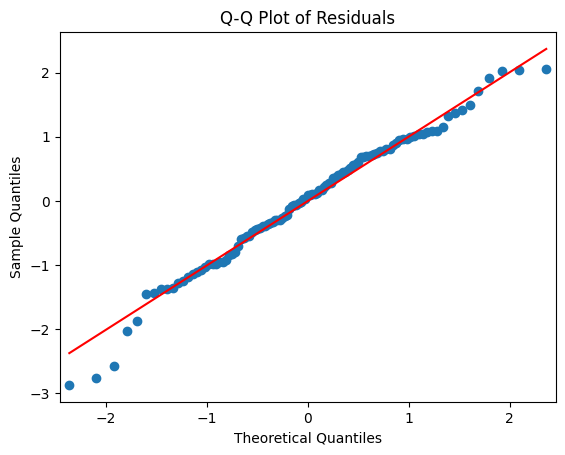

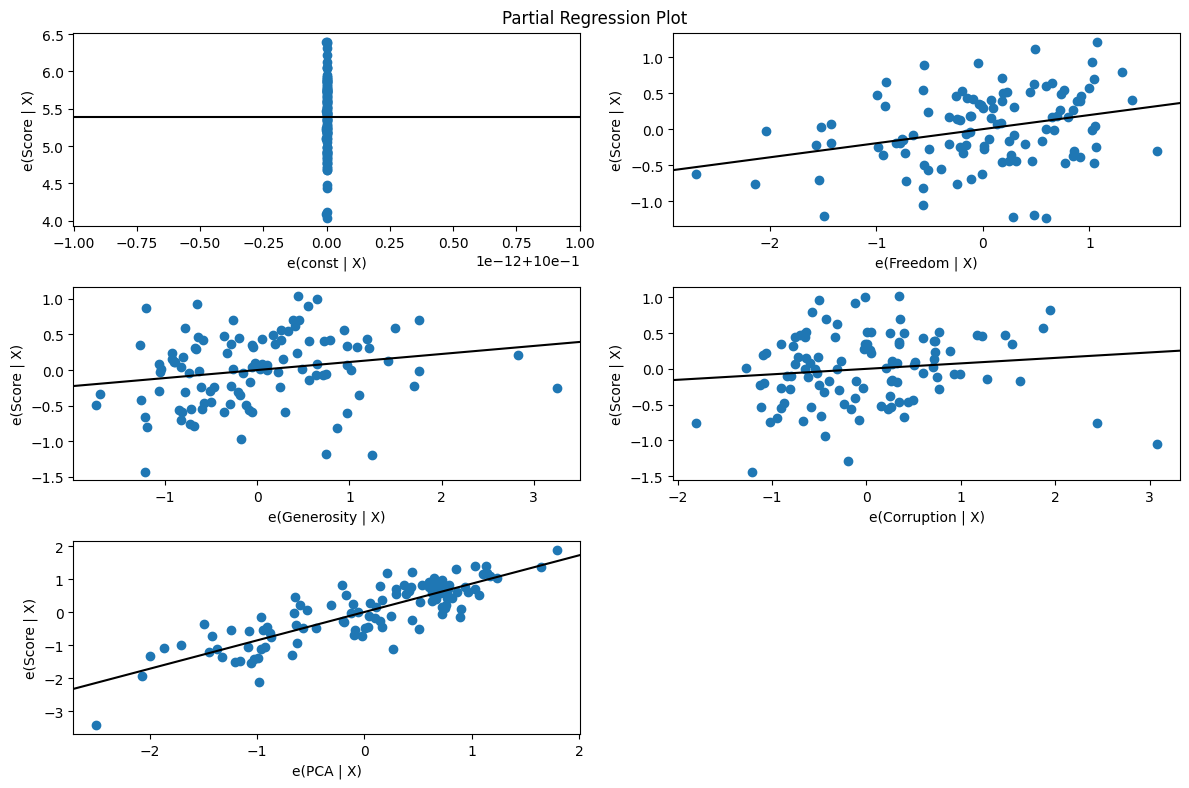

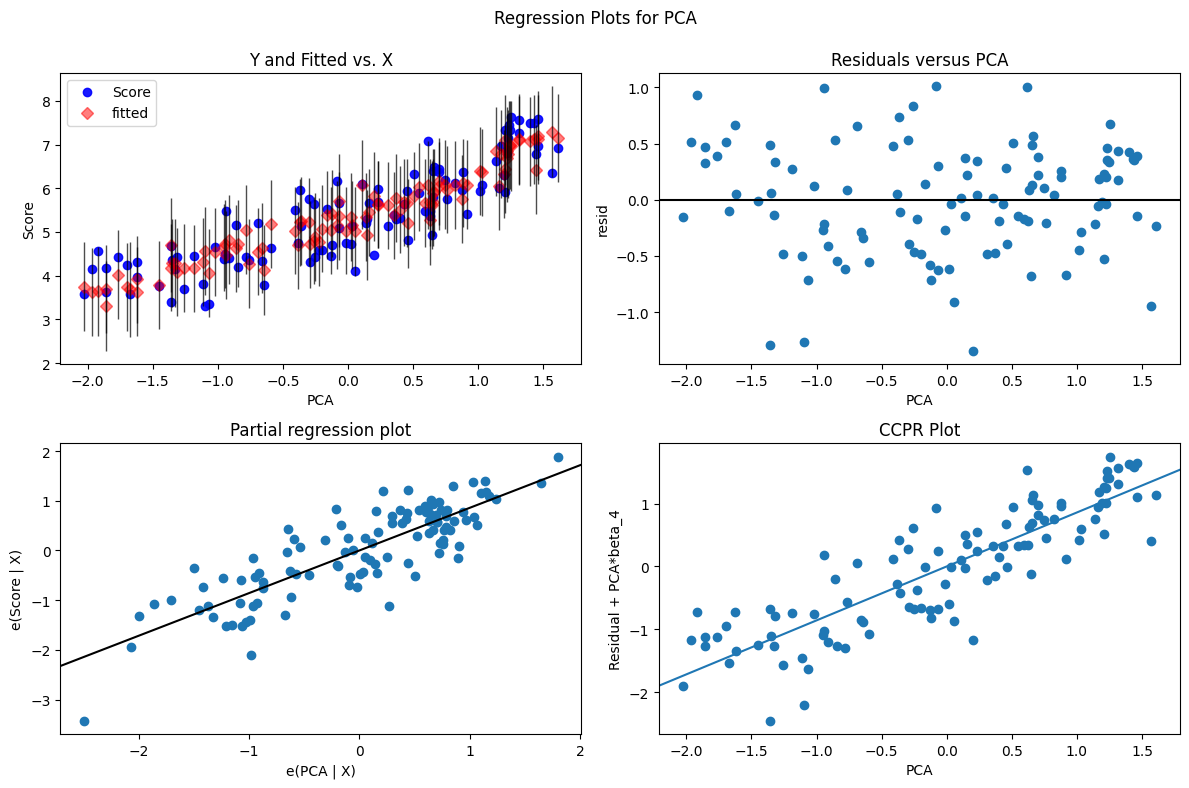

<Figure size 1200x1200 with 0 Axes>

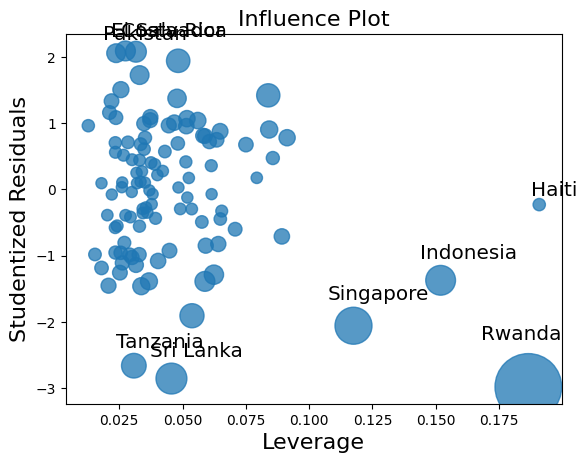

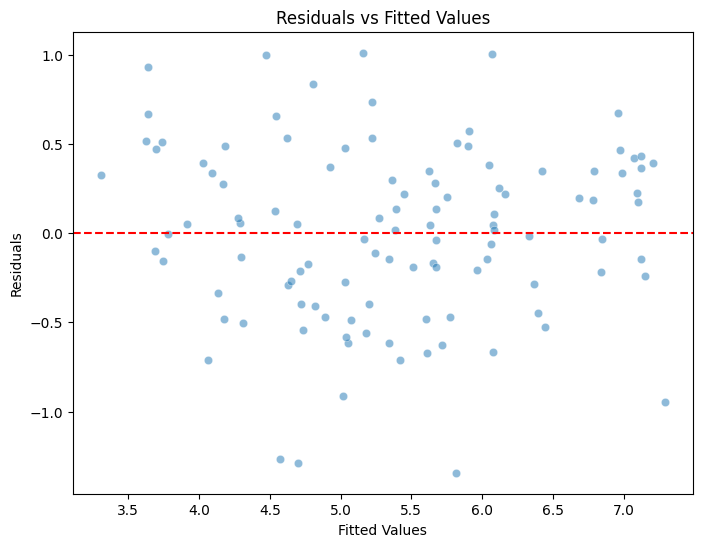

In [20]:
# QQ-plot of residuals
qq = sm.qqplot(data = OLS.get_influence().resid_studentized_internal, line="s")
plt.title("Q-Q Plot of Residuals")
plt.show()

# Partial regression plots for each predictor
sm.graphics.plot_partregress_grid(OLS, fig=plt.figure(figsize=(12, 8)))
plt.show()

# Partial regression plot for a specific predictor
sm.graphics.plot_regress_exog(OLS, "PCA", fig=plt.figure(figsize=(12, 8)))
plt.show()

# Influence diagnostics
influence = sm.graphics.influence_plot(OLS, criterion="cooks", fig=plt.figure(figsize=(12, 12)))
plt.show()

# Residuals vs Fitted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=OLS.fittedvalues, y=OLS.resid, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

In [21]:
from sklearn.metrics import mean_absolute_error as MAE, mean_squared_error as MSE, r2_score as R2
OLS_preds = OLS.predict(X_test)
results = {"OLS": {"MSE": MSE(y_test, OLS_preds), "MAE": MAE(y_test, OLS_preds), "R2": R2(y_test, OLS_preds)}}
print(f"MSE: {MSE(y_test, OLS_preds)}, MAE: {MAE(y_test, OLS_preds)}, R2: {R2(y_test, OLS_preds)}")

MSE: 0.34337359019670527, MAE: 0.4435352442782492, R2: 0.7124749712391782


## Regularized OLS

In [22]:
# Fit regularized OLS
OLS_reg = sm.OLS(y_train, X_train).fit_regularized(alpha = 0.3, L1_wt = 1, refit=True)
print(OLS_reg.summary())

OLS_reg_preds = OLS_reg.predict(X_test)
# Add performance to results dictionary
results["OLS_reg"] = {"MSE": MSE(y_test, OLS_reg_preds), "MAE": MAE(y_test, OLS_reg_preds), "R2": R2(y_test, OLS_reg_preds)}
print(f"MSE: {MSE(y_test, OLS_reg_preds)}, MAE: {MAE(y_test, OLS_reg_preds)}, R2: {R2(y_test, OLS_reg_preds)}")
print(f"R2 train: {R2(y_train, OLS_reg.predict(X_train))}")

                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.799
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     140.3
Date:                Sun, 27 Jul 2025   Prob (F-statistic):           9.09e-37
Time:                        18:06:33   Log-Likelihood:                -80.163
No. Observations:                 109   AIC:                             168.3
Df Residuals:                     106   BIC:                             179.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.3857      0.049    109.834      0.0

       alpha        MSE
0   0.000100   0.262595
1   0.000359   0.262595
2   0.001292   0.262595
3   0.004642   0.262595
4   0.016681   0.262872
5   0.059948   0.268647
6   0.215443   0.277242
7   0.774264   0.328210
8   2.782559   1.282817
9  10.000000  30.260137


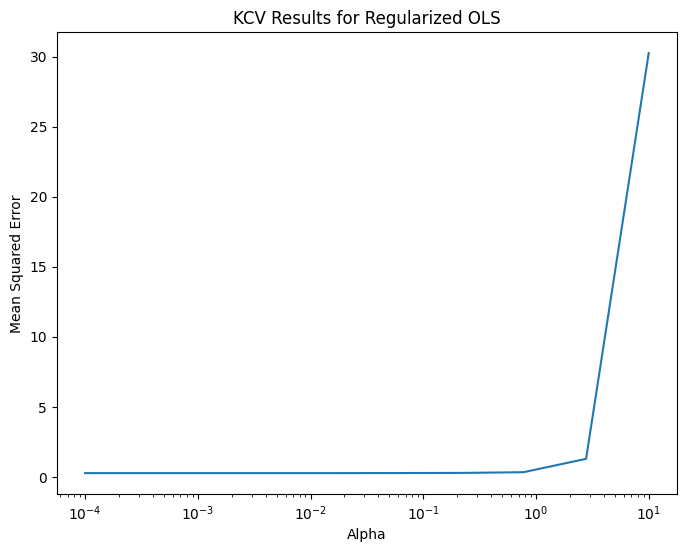

Best alpha from KCV: 0.0001
                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     90.55
Date:                Sun, 27 Jul 2025   Prob (F-statistic):           2.79e-36
Time:                        18:06:33   Log-Likelihood:                -76.123
No. Observations:                 109   AIC:                             164.2
Df Residuals:                     104   BIC:                             180.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.3857   

In [23]:
# Implement KCV for regularization tuning using statsmodels
from sklearn.model_selection import KFold
def kcv_regularized_ols(X, y, alphas, l1_wt=1, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    results = []

    for alpha in alphas:
        mse_scores = []
        for train_index, test_index in kf.split(X):
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train, y_test = y.iloc[train_index], y.iloc[test_index]
            model = sm.OLS(y_train, X_train).fit_regularized(alpha=alpha, L1_wt=l1_wt, refit=True)
            preds = model.predict(X_test)
            mse_scores.append(MSE(y_test, preds))
        results.append({"alpha": alpha, "MSE": np.mean(mse_scores)})

    return pd.DataFrame(results)
alphas = np.logspace(-4, 1, 10)
kcv_results = kcv_regularized_ols(X_train, y_train, alphas)
print(kcv_results)
# Plot KCV results
plt.figure(figsize=(8, 6))
sns.lineplot(data=kcv_results, x="alpha", y="MSE")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Mean Squared Error")
plt.title("KCV Results for Regularized OLS")
plt.show()
# Best alpha from KCV
best_alpha = kcv_results.loc[kcv_results["MSE"].idxmin(), "alpha"]
print(f"Best alpha from KCV: {best_alpha}")
# Fit final regularized OLS model with best alpha
OLS_KCV = sm.OLS(y_train, X_train).fit_regularized(alpha=best_alpha, L1_wt=1, refit=True)
print(OLS_KCV.summary())
OLS_KCV_preds = OLS_KCV.predict(X_test)
# Add performance to results dictionary
results["OLS_KCV"] = {"MSE": MSE(y_test, OLS_KCV_preds), "MAE": MAE(y_test, OLS_KCV_preds), "R2": R2(y_test, OLS_KCV_preds)}

In [24]:
## XGB
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=1000, learning_rate=0.01, random_state=42)
xgb.fit(X_train.drop("const", axis=1), y_train)
xgb_preds = xgb.predict(X_test.drop("const", axis=1))
# Add performance to results dictionary
results["XGB"] = {"MSE": MSE(y_test, xgb_preds), "MAE": MAE(y_test, xgb_preds), "R2": R2(y_test, xgb_preds)}
print(f"MSE: {MSE(y_test, xgb_preds)}, MAE: {MAE(y_test, xgb_preds)}, R2: {R2(y_test, xgb_preds)}")

MSE: 0.5198374627237516, MAE: 0.5726307265910696, R2: 0.564712355032966


## LightGBM

In [25]:
from lightgbm import LGBMRegressor
# Fit LightGBM model
lgbm = LGBMRegressor(n_estimators=1000, random_state=42, learning_rate=0.01)
lgbm.fit(X_train, y_train, eval_set=[(X_test, y_test)], eval_metric='mse')
# Predict with LightGBM
lgbm_preds = lgbm.predict(X_test)
# Evaluate LightGBM performance
print(f"LightGBM MSE: {MSE(y_test, lgbm_preds)}, MAE: {MAE(y_test, lgbm_preds)}, R2: {R2(y_test, lgbm_preds)}")
# Append to performance dictionary
results["LGBM"] = {"MSE": MSE(y_test, lgbm_preds), "MAE": MAE(y_test, lgbm_preds), "R2": R2(y_test, lgbm_preds)}


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000327 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 146
[LightGBM] [Info] Number of data points in the train set: 109, number of used features: 4
[LightGBM] [Info] Start training from score 5.385688
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

## GAM

In [67]:
x_corruption = X_train['Corruption']
from statsmodels.gam.api import GLMGam, BSplines
smoother=BSplines(X_train["Corruption"], df=6, 
          include_intercept=False, 
          degree=5)
GAM = sm.GLMGam(y_train, X_train.drop("Corruption", axis=1), 
          family=sm.families.Gaussian(link=sm.families.links.Identity()), 
          smoother=smoother
          ).fit()
print(GAM.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Score   No. Observations:                  109
Model:                         GLMGam   Df Residuals:                   100.00
Model Family:                Gaussian   Df Model:                         8.00
Link Function:               Identity   Scale:                         0.22714
Method:                         PIRLS   Log-Likelihood:                -69.188
Date:                Sun, 27 Jul 2025   Deviance:                       22.714
Time:                        18:28:46   Pearson chi2:                     22.7
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9906
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             5.2761      0.201     26.224

In [50]:
# Prepare test data
X_test_param = X_test.drop(columns="Corruption")

# Predict (returns response scale, no transformation needed)
y_pred = GAM.predict(X_test_param, exog_smooth=X_test[["Corruption"]])

# Evaluate GAM performance
gam_mse = MSE(y_test, y_pred)
gam_mae = MAE(y_test, y_pred)
gam_r2 = R2(y_test, y_pred)
# Append GAM performance to results dictionary
results["GAM"] = {"MSE": gam_mse, "MAE": gam_mae, "R2": gam_r2}
print(f"GAM MSE: {gam_mse}, MAE: {gam_mae}, R2: {gam_r2}")

GAM MSE: 0.3261285527422025, MAE: 0.44842236436987, R2: 0.726915161258588


Approximate EDF for 'Corruption': 5 / 5


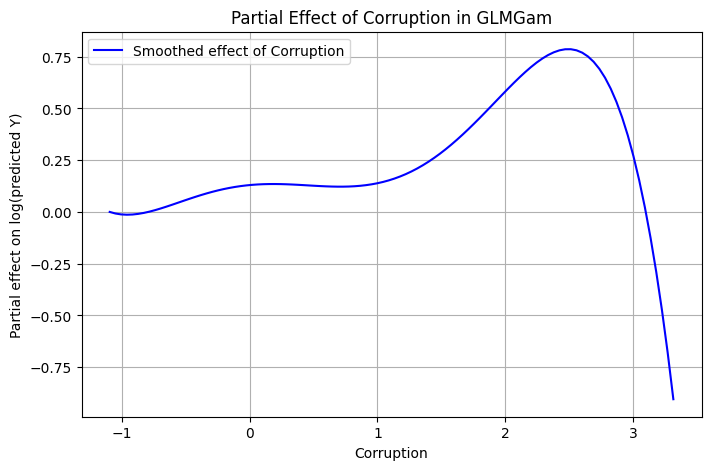

In [59]:
# Number of basis functions for the smoothed term (approximate EDF if unpenalized)
n_basis = smoother.transform(np.array(X_train[["Corruption"]])).shape[1]

# Get the estimated parameters for the smoother
smooth_params = GAM.params[-n_basis:]

# Approximate EDF: number of coefficients significantly different from 0
edf_estimate = np.sum(np.abs(smooth_params) > 1e-4)
print(f"Approximate EDF for 'Corruption': {edf_estimate} / {n_basis}")

# 1. Generate a range of values for Corruption
x_vals = np.linspace(x_corruption.min(), x_corruption.max(), 100)

# 3. Transform the new x_vals using the same smoother
Z = smoother.transform(x_vals)

# 4. Extract the coefficients corresponding to the smoother part
# These are the last `Z.shape[1]` coefficients
smooth_params = GAM.params[-Z.shape[1]:]

# 5. Compute the smoothed effect
smoothed_effect = Z @ smooth_params

# 6. Plot the partial effect
plt.figure(figsize=(8, 5))
plt.plot(x_vals, smoothed_effect, label="Smoothed effect of Corruption", color="blue")
plt.xlabel("Corruption")
plt.ylabel("Partial effect on log(predicted Y)")
plt.title("Partial Effect of Corruption in GLMGam")
plt.legend()
plt.grid(True)
plt.show()

## TabPFN

In [27]:
# from tabpfn import TabPFNRegressor
# tabpfn = TabPFNRegressor(n_estimators=8, random_state=42)
# tabpfn.fit(X_train.drop("const", axis=1), y_train)
# tabpfn_preds = tabpfn.predict(X_test.drop("const", axis=1))
# # Add performance to results dictionary
# results["TabPFN"] = {"MSE": MSE(y_test, tabpfn_preds), "MAE": MAE(y_test, tabpfn_preds), "R2": R2(y_test, tabpfn_preds)}
# print(f"TabPFN MSE: {MSE(y_test, tabpfn_preds)}, MAE: {MAE(y_test, tabpfn_preds)}, R2: {R2(y_test, tabpfn_preds)}")

In [39]:
# Final model comparison
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="R2", ascending=False)
print(results_df)

              MSE       MAE        R2
OLS_reg  0.315553  0.410234  0.735771
GAM      0.326626  0.424647  0.726499
OLS      0.343374  0.443535  0.712475
OLS_KCV  0.343374  0.443535  0.712475
LGBM     0.374401  0.486978  0.686494
XGB      0.519837  0.572631  0.564712
